## **Lab Assignment 2**

In [37]:
!pip install memory_profiler matplotlib pandas numpy


# Problem 1 – TV Commercial Scheduling (Greedy Job Sequencing)

In [38]:
import random, time
from memory_profiler import memory_usage
import matplotlib.pyplot as plt
import pandas as pd

def job_sequencing(jobs, max_deadline):
    jobs.sort(key=lambda x: x[2], reverse=True)
    slots = [-1]*max_deadline
    total_profit = 0
    selected = []
    for job in jobs:
        for t in range(min(max_deadline, job[1])-1, -1, -1):
            if slots[t] == -1:
                slots[t] = job[0]
                total_profit += job[2]
                selected.append(job)
                break
    return selected, total_profit

jobs = [("A",2,100),("B",1,19),("C",2,27),("D",1,25),("E",3,15)]
sel, profit = job_sequencing(jobs,3)
print("Selected ads:", sel)
print("Total revenue:", profit)


Selected ads: [('A', 2, 100), ('C', 2, 27), ('E', 3, 15)]
Total revenue: 142


Complexity

Time = O(n²)

Space = O(n)
Suitability & Trade-offs: Greedy works well for profit-based priorities; cannot handle inter-ad dependencies.

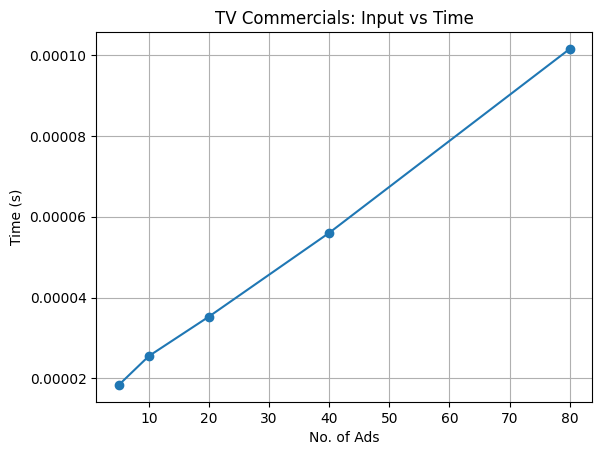

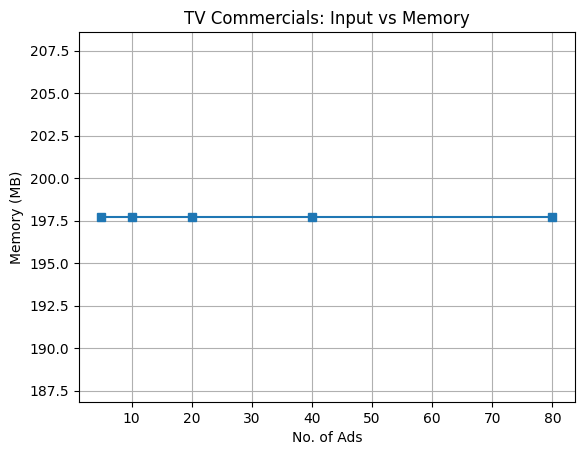

In [39]:
sizes=[5,10,20,40,80]
times=[];mems=[]
for n in sizes:
    jobs=[(f"J{i}",random.randint(1,10),random.randint(10,200)) for i in range(n)]
    start=time.time()
    job_sequencing(jobs,10)
    t=time.time()-start
    m=max(memory_usage((job_sequencing,(jobs,10))))
    times.append(t);mems.append(m)

plt.plot(sizes,times,marker='o');plt.title("TV Commercials: Input vs Time");plt.xlabel("No. of Ads");plt.ylabel("Time (s)");plt.grid();plt.show()
plt.plot(sizes,mems,marker='s');plt.title("TV Commercials: Input vs Memory");plt.xlabel("No. of Ads");plt.ylabel("Memory (MB)");plt.grid();plt.show()


# Problem 2 – Maximizing Profit with Limited Budget (0/1 Knapsack DP)

In [40]:
def knapSack(W, wt, val, n):
    K=[[0]*(W+1) for _ in range(n+1)]
    for i in range(1,n+1):
        for w in range(1,W+1):
            if wt[i-1]<=w:
                K[i][w]=max(val[i-1]+K[i-1][w-wt[i-1]],K[i-1][w])
            else:
                K[i][w]=K[i-1][w]
    return K[n][W]

weights=[10,20,30];values=[60,100,120];capacity=50
print("Max Profit =",knapSack(capacity,weights,values,len(values)))


Max Profit = 220


Complexity

Time = O(n × W)

Space = O(n × W)
Suitability & Trade-offs: Optimal for bounded choices; memory grows with capacity.

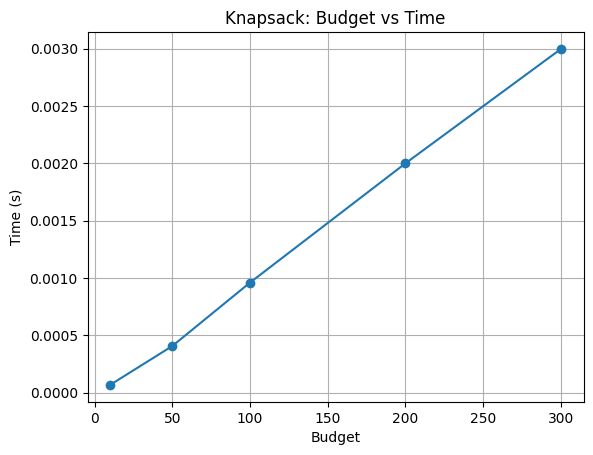

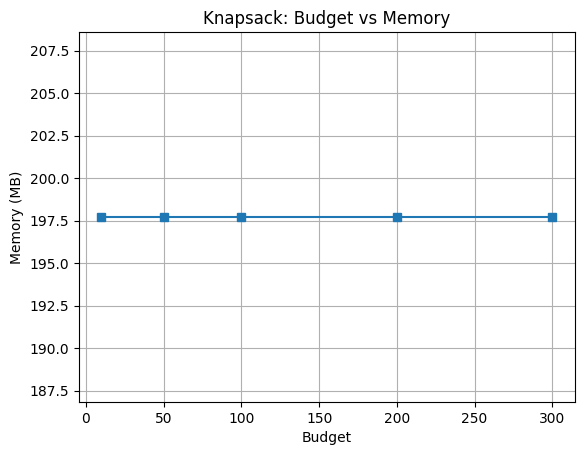

In [41]:
caps=[10,50,100,200,300];times=[];mems=[]
for c in caps:
    w=[random.randint(1,30) for _ in range(20)]
    v=[random.randint(10,100) for _ in range(20)]
    start=time.time()
    knapSack(c,w,v,len(w))
    t=time.time()-start
    m=max(memory_usage((knapSack,(c,w,v,len(w)))))
    times.append(t);mems.append(m)

plt.plot(caps,times,marker='o');plt.title("Knapsack: Budget vs Time");plt.xlabel("Budget");plt.ylabel("Time (s)");plt.grid();plt.show()
plt.plot(caps,mems,marker='s');plt.title("Knapsack: Budget vs Memory");plt.xlabel("Budget");plt.ylabel("Memory (MB)");plt.grid();plt.show()


# Problem 3 – Sudoku Solver (Backtracking)

In [42]:
def is_safe(board,row,col,num):
    for i in range(9):
        if board[row][i]==num or board[i][col]==num:
            return False
    sr,sc=3*(row//3),3*(col//3)
    for i in range(3):
        for j in range(3):
            if board[sr+i][sc+j]==num: return False
    return True

def solve_sudoku(board):
    for i in range(9):
        for j in range(9):
            if board[i][j]==0:
                for num in range(1,10):
                    if is_safe(board,i,j,num):
                        board[i][j]=num
                        if solve_sudoku(board): return True
                        board[i][j]=0
                return False
    return True

board=[[5,3,0,0,7,0,0,0,0],
       [6,0,0,1,9,5,0,0,0],
       [0,9,8,0,0,0,0,6,0],
       [8,0,0,0,6,0,0,0,3],
       [4,0,0,8,0,3,0,0,1],
       [7,0,0,0,2,0,0,0,6],
       [0,6,0,0,0,0,2,8,0],
       [0,0,0,4,1,9,0,0,5],
       [0,0,0,0,8,0,0,7,9]]

print("Solving Sudoku...")
start=time.time()
solve_sudoku(board)
print("Solved in %.4f s"% (time.time()-start))
for row in board: print(row)


Solving Sudoku...
Solved in 0.0320 s
[5, 3, 4, 6, 7, 8, 9, 1, 2]
[6, 7, 2, 1, 9, 5, 3, 4, 8]
[1, 9, 8, 3, 4, 2, 5, 6, 7]
[8, 5, 9, 7, 6, 1, 4, 2, 3]
[4, 2, 6, 8, 5, 3, 7, 9, 1]
[7, 1, 3, 9, 2, 4, 8, 5, 6]
[9, 6, 1, 5, 3, 7, 2, 8, 4]
[2, 8, 7, 4, 1, 9, 6, 3, 5]
[3, 4, 5, 2, 8, 6, 1, 7, 9]


Complexity

Worst = O(9^(n²)) ≈ very large

Average = depends on puzzle density

Space = O(n²) + recursion stack
Trade-offs: Exact solution but slow for complex grids; deep recursion → stack risk.

# Problem 4 – Password Cracking (Brute-Force)

In [43]:
import itertools,string

def brute_force_password(target,charset):
    attempt=0
    for length in range(1,len(target)+1):
        for guess in itertools.product(charset,repeat=length):
            attempt+=1
            if ''.join(guess)==target:
                return attempt

target="ab1"
charset="abc123"
start=time.time()
attempts=brute_force_password(target,charset)
print(f"Password found in {attempts} attempts, time = {time.time()-start:.3f}s")


Password found in 52 attempts, time = 0.000s


Complexity

Time = O(c^L) (c = charset size, L = length)

Space = O(1)
Trade-offs: Guaranteed but explodes exponentially; used only for security testing.

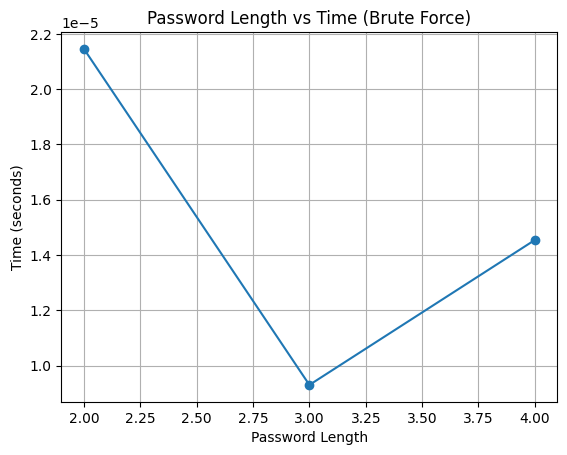

In [44]:
lengths=[2,3,4]
times=[]
for L in lengths:
    pw="a"*L
    start=time.time()
    brute_force_password(pw,"abc")
    times.append(time.time()-start)

plt.plot(lengths,times,marker='o')
plt.title("Password Length vs Time (Brute Force)")
plt.xlabel("Password Length")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.show()
